Libraries imported successfully!
Dataset Loaded | Total Listings: 48895 | Features: 16
id                                    0
name                                 16
host_id                               0
host_name                            21
neighbourhood_group                   0
neighbourhood                         0
latitude                              0
longitude                             0
room_type                             0
price                                 0
minimum_nights                        0
number_of_reviews                     0
last_review                       10052
reviews_per_month                 10052
calculated_host_listings_count        0
availability_365                      0
dtype: int64
After Cleaning: 48549 listings remaining


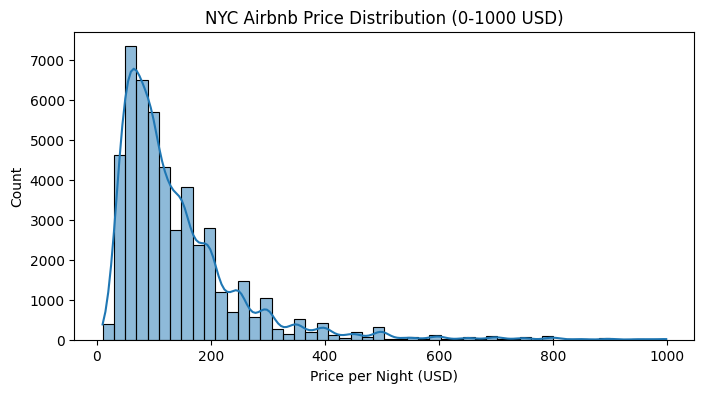

Average Price by Borough:
 neighbourhood_group
Manhattan        177.380512
Brooklyn         117.310348
Staten Island     96.148649
Queens            94.544682
Bronx             84.488029
Name: price, dtype: float64


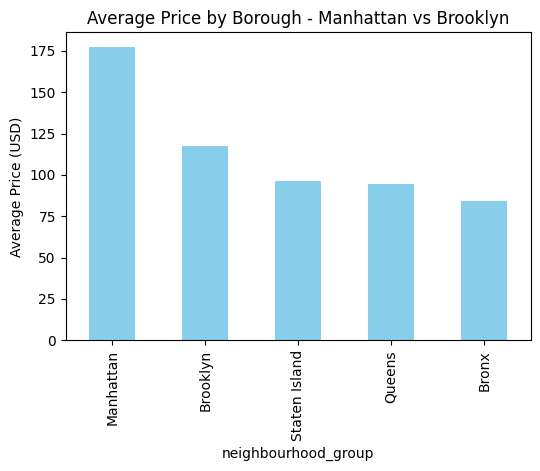

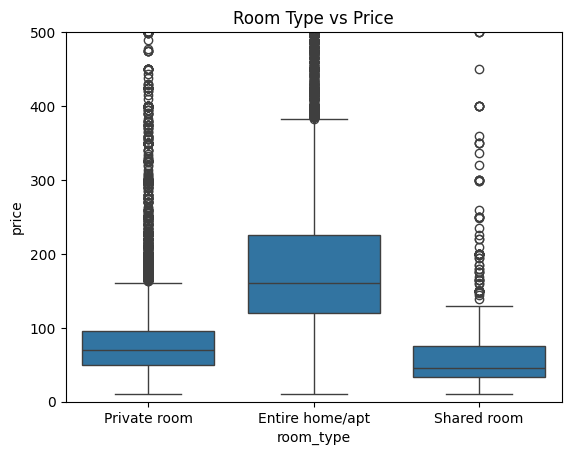

Features for Model: ['minimum_nights', 'number_of_reviews', 'availability_365', 'neighbourhood_group_Brooklyn', 'neighbourhood_group_Manhattan', 'neighbourhood_group_Queens', 'neighbourhood_group_Staten Island', 'room_type_Private room', 'room_type_Shared room']
Training Set: 38839 | Test Set: 9710
Model Training Completed!
Model Performance:
 R2 Score: 0.291
 Mean Absolute Error: $55.80


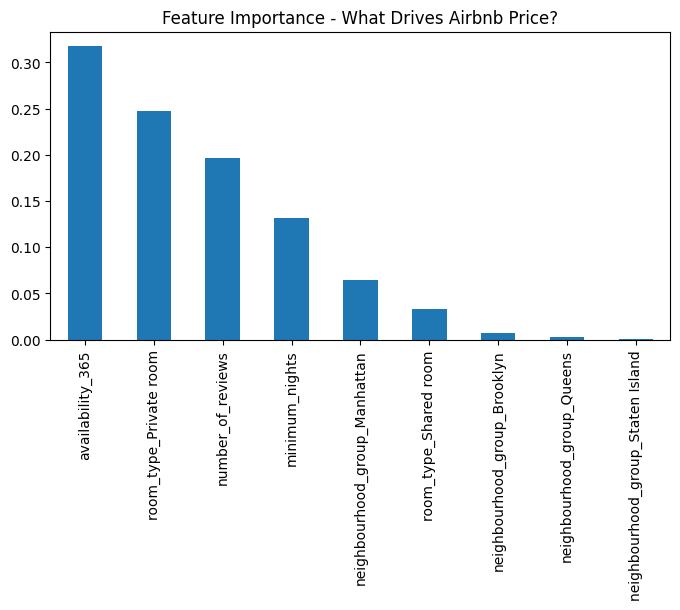

Sample Prediction: For given property, predicted price is $149.84 per night


In [1]:
# =================================================================
# NYC AIRBNB PRICE PREDICTION | AI + MACHINE LEARNING PROJECT
# Dataset: 48,895 Airbnb listings - NYC Open Data
# Author: Dhaaru - Aspiring AI Engineer
# =================================================================

# STEP 1: IMPORT LIBRARIES
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error

print("Libraries imported successfully!")

# STEP 2: LOAD DATASET
df = pd.read_csv('AB_NYC_2019.csv')
print(f"Dataset Loaded | Total Listings: {df.shape[0]} | Features: {df.shape[1]}")
df.head()

# STEP 3: DATA CLEANING & PREPROCESSING
print(df.isnull().sum())
df = df[(df['price'] > 0) & (df['price'] < 1000)] # Removing extreme outliers
df = df.dropna(subset=['name','host_name'])
print(f"After Cleaning: {df.shape[0]} listings remaining")

# STEP 4: EXPLORATORY DATA ANALYSIS (EDA)

# 4.1 Price Distribution
plt.figure(figsize=(8,4))
sns.histplot(df['price'], bins=50, kde=True)
plt.title('NYC Airbnb Price Distribution (0-1000 USD)')
plt.xlabel('Price per Night (USD)')
plt.show()

# 4.2 Average Price by Borough (Business Insight)
borough_price = df.groupby('neighbourhood_group')['price'].mean().sort_values(ascending=False)
print("Average Price by Borough:\n", borough_price)

plt.figure(figsize=(6,4))
borough_price.plot(kind='bar', color='skyblue')
plt.title('Average Price by Borough - Manhattan vs Brooklyn')
plt.ylabel('Average Price (USD)')
plt.show()

# 4.3 Room Type vs Price
sns.boxplot(x='room_type', y='price', data=df)
plt.title('Room Type vs Price')
plt.ylim(0,500)
plt.show()

# STEP 5: FEATURE ENGINEERING
# Converting categorical to numerical
df_model = pd.get_dummies(df[['neighbourhood_group','room_type','minimum_nights','number_of_reviews','availability_365','price']], drop_first=True)

X = df_model.drop('price', axis=1)
y = df_model['price']

print(f"Features for Model: {list(X.columns)}")

# STEP 6: TRAIN-TEST SPLIT
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Training Set: {X_train.shape[0]} | Test Set: {X_test.shape[0]}")

# STEP 7: AI MODEL - RANDOM FOREST REGRESSOR
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)
print("Model Training Completed!")

# STEP 8: MODEL EVALUATION
y_pred = model.predict(X_test)
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

print(f"Model Performance:\n R2 Score: {r2:.3f}\n Mean Absolute Error: ${mae:.2f}")

# STEP 9: FEATURE IMPORTANCE
importances = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=False)
plt.figure(figsize=(8,4))
importances.plot(kind='bar')
plt.title('Feature Importance - What Drives Airbnb Price?')
plt.show()

# STEP 10: PREDICTION EXAMPLE
# Example: Manhattan, Entire home, 2 nights min, 50 reviews, 200 days available
# Adjust based on your dummy columns - This is sample logic
sample = X_test.iloc[0:1]
predicted_price = model.predict(sample)
print(f"Sample Prediction: For given property, predicted price is ${predicted_price[0]:.2f} per night")